## Homework 3 ICA_oop: rewritten from Lecture 03_ICA.jpynb

In [5]:
import numpy as np

class FastICA:
    def __init__(self, alpha = 1, thresh=1e-8, iterations=5000):
        self.alpha = alpha
        self.thresh = thresh
        self.iterations = iterations
        self.mean = None
        self.Xw = None
        self.W = None
        
    def center(self, X):
        self.mean = np.mean(X, axis=1, keepdims=True)
        return X - self.mean
    def covariance(self, X):
        n_samples = X.shape[1] - 1
        return np.dot(X, X.T) / n_samples
    def whiten(self, X):
        coVarM = self.covariance(X)
        U, S, V = np.linalg.svd(coVarM)
        d = np.diag(1.0 / np.sqrt(S))
        whiteM = np.dot(d, U.T)
        self.Xw = np.dot(whiteM, X)
        return self.Xw
    def fit(self, X):
        # Center signals
        X_centered = self.center(X)
        # Whiten mixed signals
        X_whitened = self.whiten(X_centered)
        m = X.shape[0]
        
        # Initialize random weights
        np.random.seed(23)
        self.W = np.zeros((m, m))
        for c in range(m):
            w = np.random.rand(m)
            w = w / np.linalg.norm(w)
            
            i = 0
            lim = 100
            while (lim > self.thresh) and (i < self.iterations):
                ws = np.dot(w.T, X_whitened)
                
                wg = np.tanh(ws * self.alpha)
                wg_ = self.alpha * (1 - np.square(wg))
                
                wNew = (X_whitened * wg).mean(axis=1) - wg_.mean() * w
                
                if c > 0:
                    wNew = wNew - np.dot(np.dot(wNew, self.W[:c].T), self.W[:c])
                
                wNew = wNew / np.linalg.norm(wNew)
                
                lim = np.abs(np.abs(np.dot(wNew, w)) - 1)
                
                w = wNew
                i += 1
                
            self.W[c, :] = w

        return self.W


    def unmix(self):
        # #Un-mix signals 
        return np.dot(self.W, self.Xw)


In [7]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Enable plots inside the Jupyter NotebookLet the
%matplotlib inline

In [14]:
# Set a seed for the random number generator for reproducibility
np.random.seed(23)
# Number of samples
ns = np.linspace(0, 200, 1000)
# Source matrix
S = np.array([np.sin(ns * 1), 
              signal.sawtooth(ns * 1.9),
              np.random.random(len(ns))]).T
S = S.T
# Mixing matrix
A = np.array([[0.5, 1, 0.2], 
              [1, 0.5, 0.4], 
              [0.5, 0.8, 1]])
# Mixed signal matrix
# X = S.dot(A).T
X = A.dot(S)
print(ns.shape, S.shape, A.shape, X.shape)

(1000,) (3, 1000) (3, 3) (3, 1000)


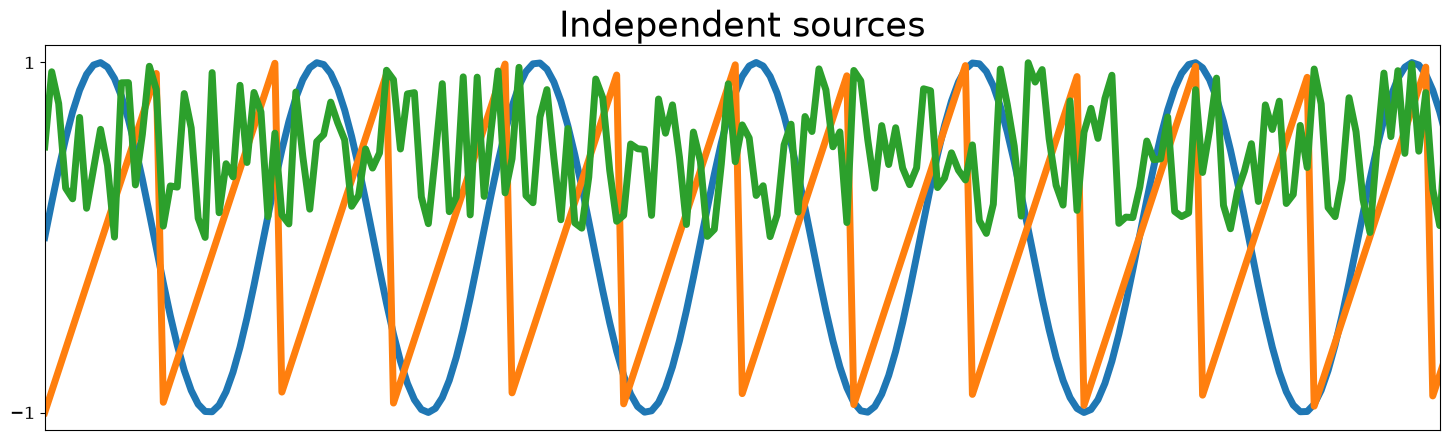

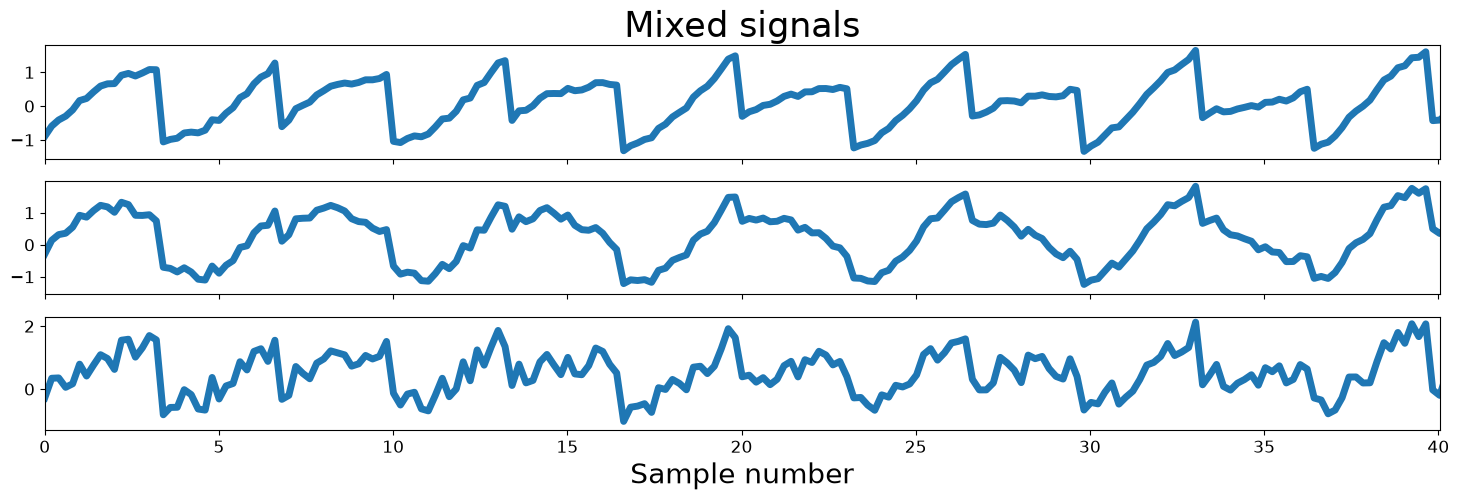

In [9]:
# Plot sources & signals
fig, ax = plt.subplots(1, 1, figsize=[18, 5])
ax.plot(ns, S.T, lw=5)
ax.set_xticks([])
ax.set_yticks([-1, 1])
ax.set_xlim(ns[0], ns[200])
ax.tick_params(labelsize=12)
ax.set_title('Independent sources', fontsize=25)

fig, ax = plt.subplots(3, 1, figsize=[18, 5], sharex=True)
ax[0].plot(ns, X[0], lw=5)
ax[0].set_title('Mixed signals', fontsize=25)
ax[0].tick_params(labelsize=12)

ax[1].plot(ns, X[1], lw=5)
ax[1].tick_params(labelsize=12)
ax[1].set_xlim(ns[0], ns[-1])

ax[2].plot(ns, X[2], lw=5)
ax[2].tick_params(labelsize=12)
ax[2].set_xlim(ns[0], ns[-1])
ax[2].set_xlabel('Sample number', fontsize=20)
ax[2].set_xlim(ns[0], ns[200])

plt.show()

In [10]:
fastica = FastICA(alpha=1, thresh=1e-8, iterations=5000)
W = fastica.fit(X)
unMixed = fastica.unmix()
print(unMixed.shape)

(3, 1000)


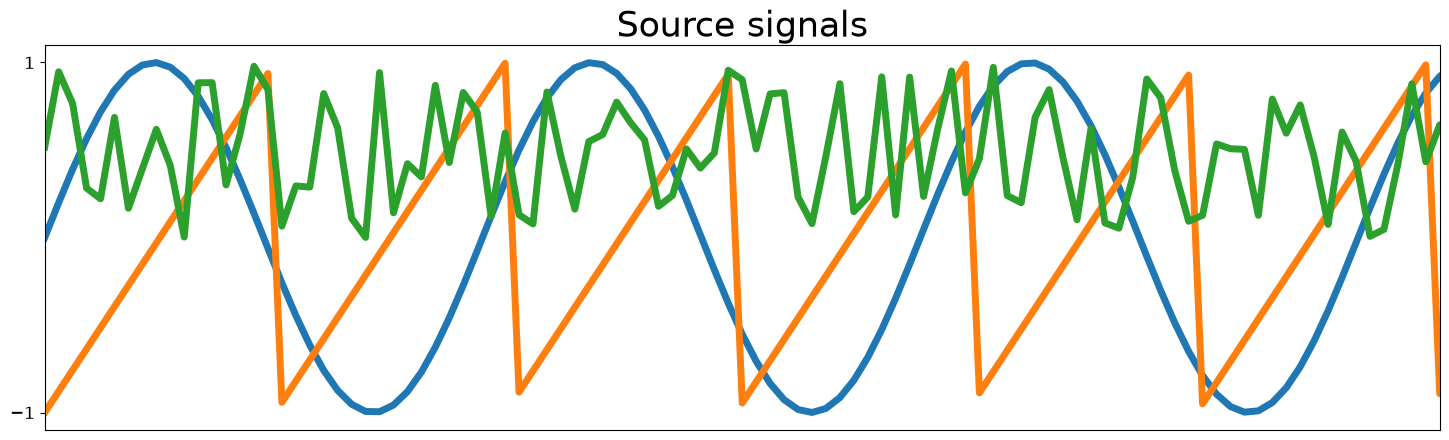

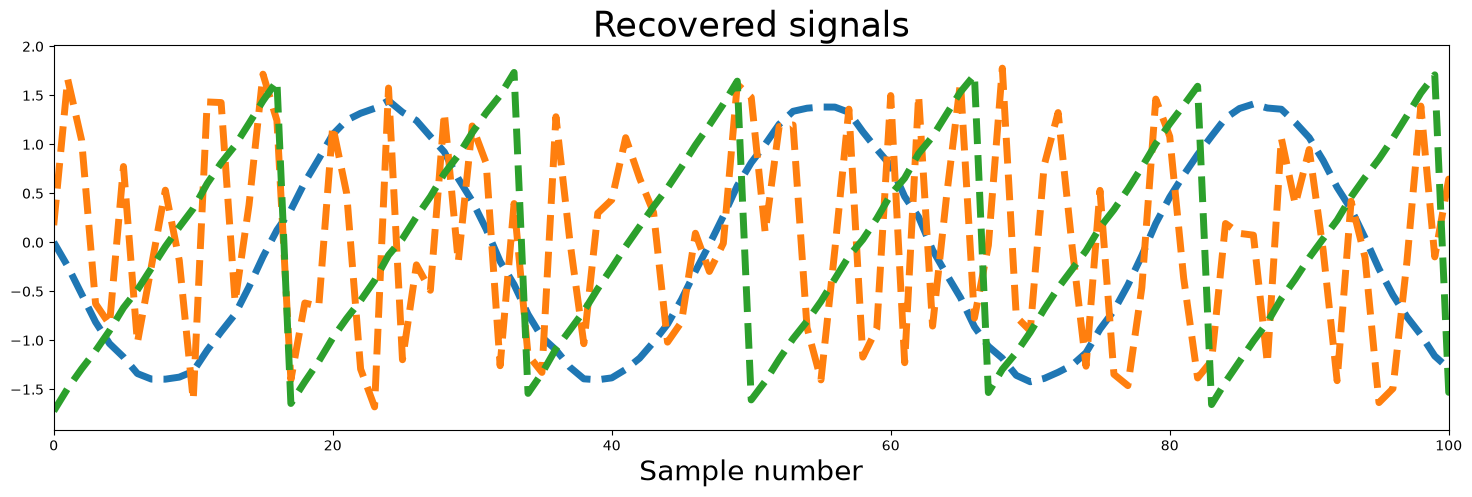

In [13]:
# Plot input signals (not mixed)
fig, ax = plt.subplots(1, 1, figsize=[18, 5])
ax.plot(S.T, lw=5)
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([-1, 1])
ax.set_title('Source signals', fontsize=25)
ax.set_xlim(0, 100)

fig, ax = plt.subplots(1, 1, figsize=[18, 5])
ax.plot(unMixed.T, '--', label='Recovered signals', lw=5)
ax.set_xlabel('Sample number', fontsize=20)
ax.set_title('Recovered signals', fontsize=25)
ax.set_xlim(0, 100)

plt.show()